### Objectives:
- Implement Decision Tree and Random Forest
- Perform regression and classification
- Analyze feature importance
- Compare model performance

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

##  Data Loading and Preprocessing

We load the feature-engineered dataset and prepare it for modeling.

In [11]:
df = pd.read_csv("../data/processed/feature_engineered_traffic.csv")

# Drop unnecessary column
df = df.drop(columns=["DateTime"])

df.head()

,Junction,Vehicles,Hour,Day,DayOfWeek,Month,Year,Is_Weekend,Is_Peak_Hour,lag_1,rolling_mean_3
0,1,15,0,1,6,11,2015,1,0,15.0,12.666667
1,1,13,1,1,6,11,2015,1,0,15.0,12.666667
2,1,10,2,1,6,11,2015,1,0,13.0,12.666667
3,1,7,3,1,6,11,2015,1,0,10.0,10.000000
4,1,9,4,1,6,11,2015,1,0,7.0,8.666667


##  Train-Test Split

We separate features and target variable (`Vehicles`) and split the data.

In [13]:
X = df.drop(columns=["Vehicles"])
y = df["Vehicles"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Decision Tree Regression

Decision Trees capture non-linear relationships by splitting the data.

In [14]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, y_pred_dt)
print("Decision Tree MSE:", dt_mse)

Decision Tree MSE: 13.334216261255234


##  Random Forest Regression

Random Forest improves performance by combining multiple trees (ensemble learning).

In [16]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
print("Random Forest MSE:", rf_mse)

Random Forest MSE: 6.487074931588466


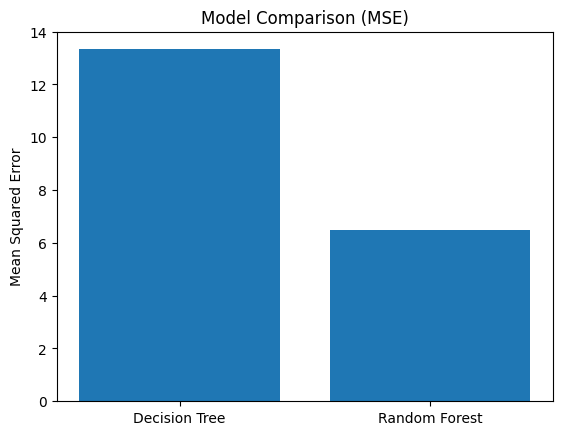

In [17]:
models = ["Decision Tree", "Random Forest"]
mse_values = [dt_mse, rf_mse]

plt.figure()
plt.bar(models, mse_values)
plt.title("Model Comparison (MSE)")
plt.ylabel("Mean Squared Error")
plt.show()

##  Feature Importance

Feature importance shows which variables influence traffic prediction the most.

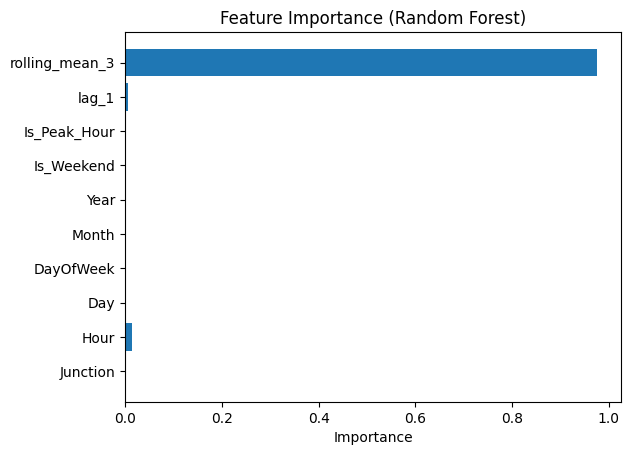

In [19]:
importances = rf.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

##  Traffic Classification

We convert continuous traffic values into categories:
- Low
- Medium
- High

In [20]:
df["Traffic_Level"] = pd.qcut(
    df["Vehicles"],
    q=3,
    labels=["Low", "Medium", "High"]
)

X = df.drop(columns=["Vehicles", "Traffic_Level"])
y = df["Traffic_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Random Forest Classification

We classify traffic congestion levels using Random Forest.

In [21]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.920303408146301


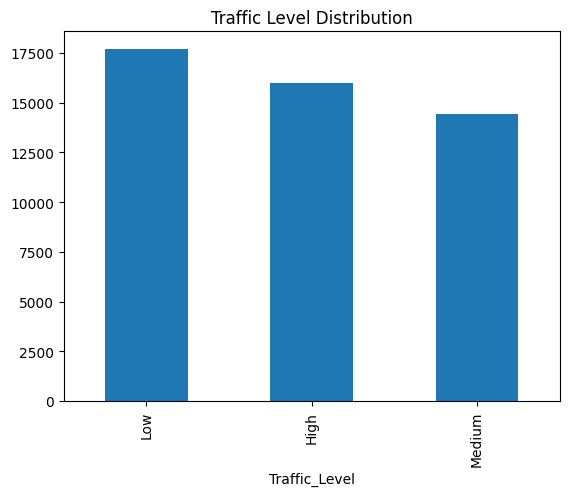

In [22]:
df["Traffic_Level"].value_counts().plot(kind="bar")
plt.title("Traffic Level Distribution")
plt.show()

##  Conclusion

- Decision Trees capture non-linear patterns but may overfit.
- Random Forest provides better generalization.
- Feature importance highlights key influencing factors.
- Classification extends the model to real-world traffic congestion prediction.

This module demonstrates the effectiveness of non-linear and ensemble models in traffic prediction.